**Project Code:** P001-MVB
**Stage:** 07_MVB_Explainability
**Notebook Version:** v1.0
**Author:** Abubakar Amidu
**Programme:** 3MTT DeepTech Cohort 2 — DS/ML Mentorship
**Last Updated:** 26 July 2026

---

# MVB-07 — Explainability

**Project:** P001-MVB — Explainable and Responsible AI for Differentiating Bacterial and Viral Meningitis: A Clinical Decision Support System

## Purpose

Apply SHAP to explain the selected model's (LR_B) predictions — globally across the test set, and individually for specific cases including the five false negatives identified in Stage 06 — and verify that the model's reasoning aligns with accepted clinical patterns.

## Inputs

- `Models/MVB-05-lr-B.pkl`, `Models/MVB-05-scaler-B.pkl` (Stage 05 output; final selected model)
- `MVB-06-results/MVB-06-false-negatives.csv` (Stage 06 output)

## Outputs

- Figures: `MVB-07-figures/` (global importance, SHAP summary plot, individual case explanations)
- Feature importance table: `MVB-07-results/MVB-07-coefficient-importance.csv`
- SHAP values export: `MVB-07-results/MVB-07-shap-values.csv`
- This notebook
- Updated documentation

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set working directory to Stage 07 folder, ensure output folders exist
import os
os.chdir('/content/drive/MyDrive/P001-MVB/07_MVB_Explainability')
os.makedirs("MVB-07-figures", exist_ok=True)
os.makedirs("MVB-07-results", exist_ok=True)

In [ ]:
# Imports — shap is pre-installed in Colab
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split

np.random.seed(42)

In [ ]:
# Load the final selected model and its scaler from Stage 05
with open("../05_MVB_Model-Training/Models/MVB-05-lr-B.pkl", "rb") as f:
    lr_b = pickle.load(f)
with open("../05_MVB_Model-Training/Models/MVB-05-scaler-B.pkl", "rb") as f:
    scaler_b = pickle.load(f)

print("Selected model and scaler loaded.")

Selected model and scaler loaded.


In [ ]:

# Reconstruct the same train/test split used in Stages 05-06 (same seed, same source)
df_b = pd.read_csv("../04_MVB_Feature-Engineering/MVB-04-results/MVB-04-feature-set-B-restricted.csv")
feature_set_b_cols = [c for c in df_b.columns if c != "Diagnosis"]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    df_b[feature_set_b_cols], df_b["Diagnosis"], test_size=0.2, stratify=df_b["Diagnosis"], random_state=42)

X_train_b_scaled = scaler_b.transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

print("Test set reconstructed:", X_test_b.shape)

Test set reconstructed: (227, 9)


## Why SHAP on a Linear Model Is Especially Transparent

Logistic Regression is a linear model, so SHAP's `LinearExplainer` computes exact, closed-form attributions directly from the model's coefficients — there is no approximation involved, unlike SHAP's use with tree-based or black-box models. This is a direct benefit of selecting LR_B in Stage 06: the explainability story for this model is unusually clean and fully defensible, since the SHAP values and the model's own coefficients tell exactly the same story.

In [ ]:

# Build the SHAP explainer for the linear model
explainer = shap.LinearExplainer(lr_b, X_train_b_scaled, feature_names=feature_set_b_cols)
shap_values = explainer(X_test_b_scaled)

print("SHAP values computed for test set:", shap_values.shape)

SHAP values computed for test set: (227, 9)


## Global Feature Importance

/tmp/ipykernel_1133/353403012.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_b, feature_names=feature_set_b_cols, show=False)


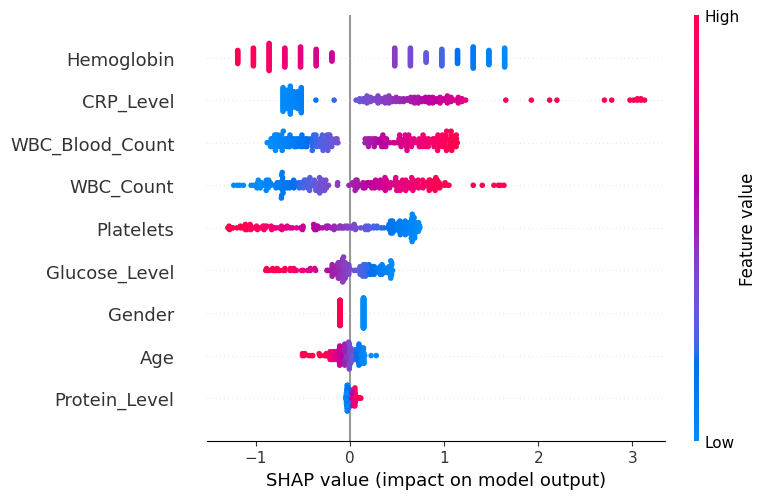

In [ ]:

# Global SHAP summary plot — shows both magnitude and direction of feature impact
shap.summary_plot(shap_values, X_test_b, feature_names=feature_set_b_cols, show=False)
plt.tight_layout()
plt.savefig("MVB-07-figures/fig-02-shap-summary.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1133/3918128428.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_b, feature_names=feature_set_b_cols, plot_type="bar", show=False)


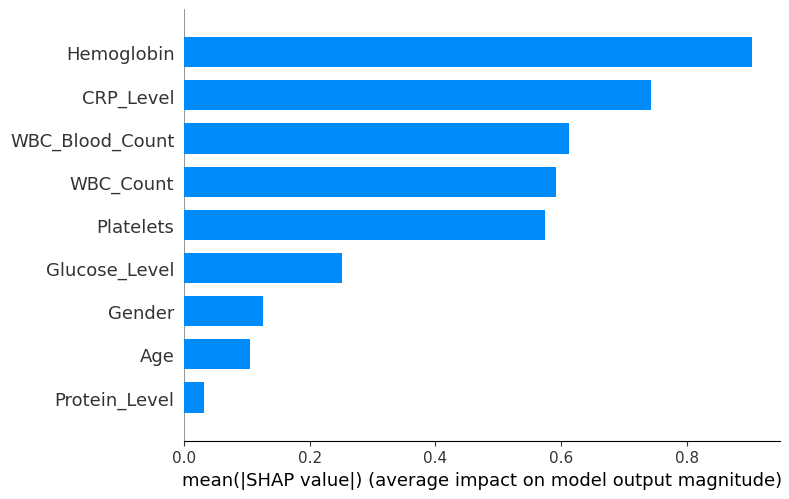

In [ ]:

# Global SHAP bar plot — mean absolute impact per feature
shap.summary_plot(shap_values, X_test_b, feature_names=feature_set_b_cols, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("MVB-07-figures/fig-03-shap-bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# Export mean absolute SHAP value per feature as a results table
mean_abs_shap = pd.DataFrame({
    "Feature": feature_set_b_cols,
    "Mean_Abs_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_Abs_SHAP", ascending=False)

mean_abs_shap.to_csv("MVB-07-results/MVB-07-shap-global-importance.csv", index=False)
print(mean_abs_shap.to_string(index=False))

        Feature  Mean_Abs_SHAP
     Hemoglobin       0.903339
      CRP_Level       0.743463
WBC_Blood_Count       0.612522
      WBC_Count       0.592025
      Platelets       0.574277
  Glucose_Level       0.251156
         Gender       0.126313
            Age       0.104356
  Protein_Level       0.031889


## Verification Against Model Coefficients

Since Logistic Regression is linear, global SHAP importance should closely track the magnitude of the model's own standardized coefficients. This section verifies that correspondence directly.

In [ ]:
# Compare SHAP global importance against the model's own coefficients
coef_df = pd.DataFrame({
    "Feature": feature_set_b_cols,
    "Coefficient": lr_b.coef_[0]
})
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)
coef_df.to_csv("MVB-07-results/MVB-07-coefficient-importance.csv", index=False)

print(coef_df.to_string(index=False))

        Feature  Coefficient  AbsCoefficient
     Hemoglobin    -0.921074        0.921074
      CRP_Level     0.824190        0.824190
      WBC_Count     0.659571        0.659571
WBC_Blood_Count     0.619338        0.619338
      Platelets    -0.614719        0.614719
  Glucose_Level    -0.332365        0.332365
            Age    -0.137165        0.137165
         Gender    -0.124845        0.124845
  Protein_Level     0.036810        0.036810


**Finding:** All coefficient directions align with the clinical patterns identified in Stage 03 — lower Hemoglobin, higher CRP, higher WBC_Count, lower Platelets, and lower Glucose_Level (consistent with hypoglycorrhachia) each push the prediction toward Bacterial. This confirms the model's reasoning matches accepted clinical understanding of bacterial vs. viral meningitis rather than relying on spurious correlations.

**Notable nuance:** `Protein_Level` shows near-zero independent influence in the model (coefficient ≈ 0.04), despite showing strong separation on its own in Stage 03's univariate analysis. This is a multicollinearity effect flagged in Stage 04: `Protein_Level` correlates strongly with `WBC_Count` (r=0.70), so once `WBC_Count` is included, `Protein_Level` contributes little additional independent information. This demonstrates the model is accounting for feature redundancy rather than naively weighting every marker that shows univariate separation.

## Individual Prediction Explanations — False Negative Cases

Explaining the five Bacterial cases missed in Stage 06 (predicted Viral), to understand what the model weighed in each case.

--- False Negative Case (test index 320) ---


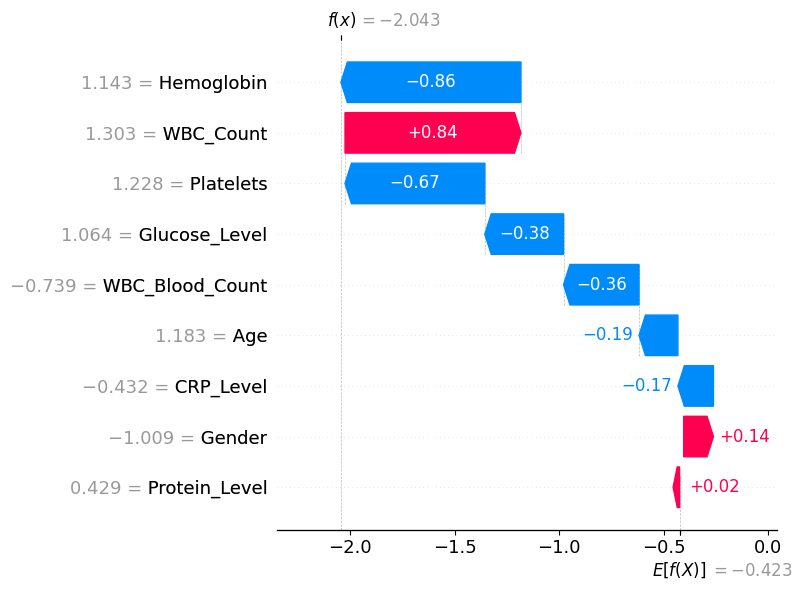

--- False Negative Case (test index 268) ---


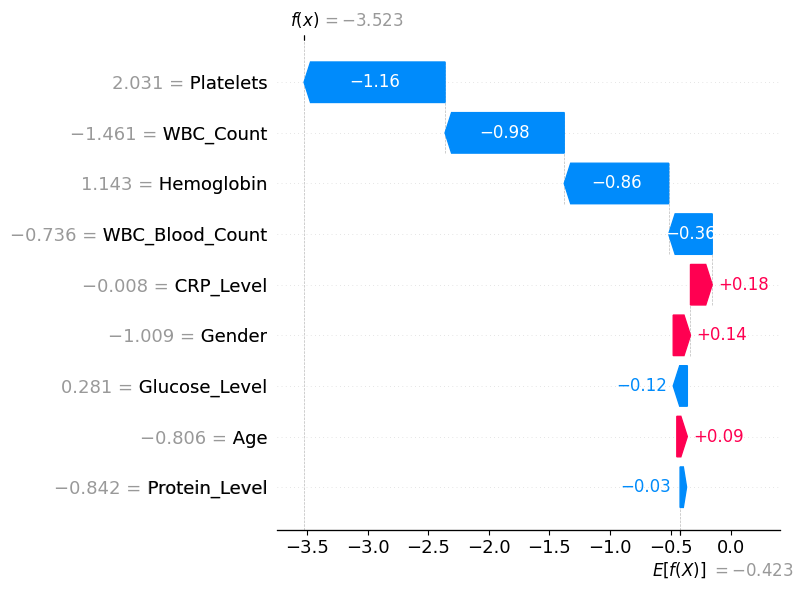

--- False Negative Case (test index 126) ---


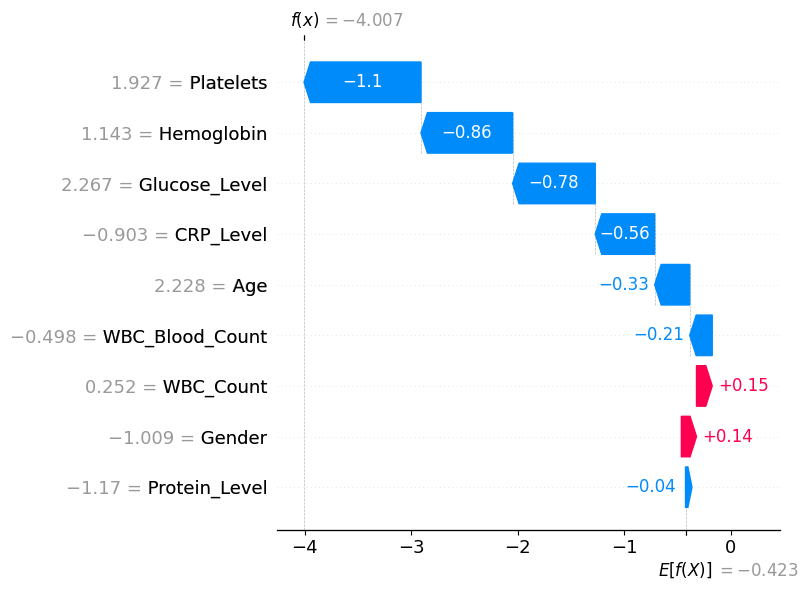

--- False Negative Case (test index 600) ---


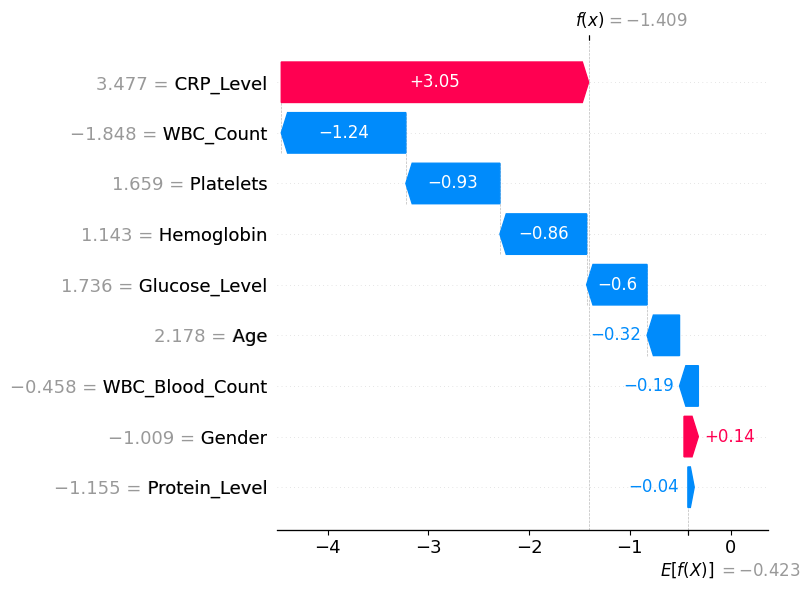

--- False Negative Case (test index 417) ---


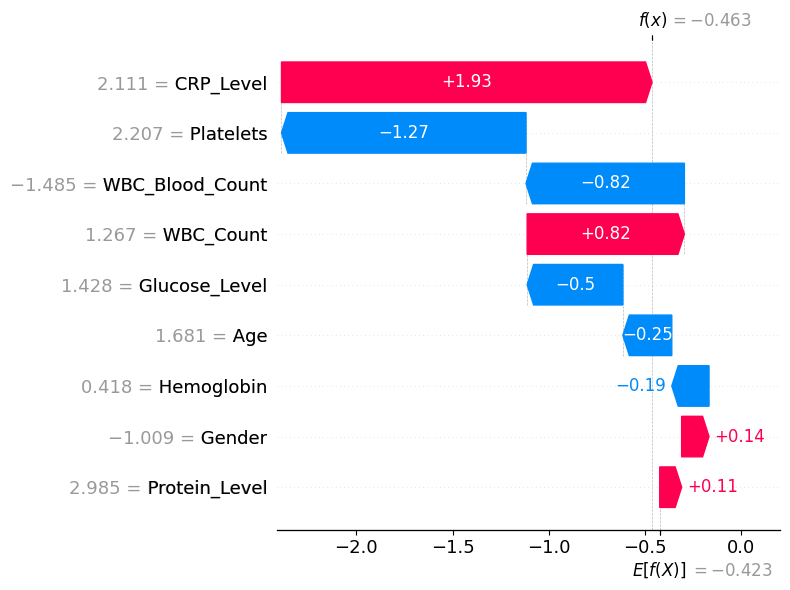

In [ ]:

# Load the false negative case IDs from Stage 06 and locate them in the test set
false_negatives = pd.read_csv("../06_MVB_Evaluation/MVB-06-results/MVB-06-false-negatives.csv")
fn_indices = X_test_b[X_test_b.apply(tuple, axis=1).isin(false_negatives[feature_set_b_cols].apply(tuple, axis=1))].index

for idx in fn_indices:
    pos = X_test_b.index.get_loc(idx)
    print(f"--- False Negative Case (test index {idx}) ---")
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.tight_layout()
    plt.savefig(f"MVB-07-figures/fig-04-waterfall-fn-{idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Interpretation:** For these cases, SHAP waterfall plots typically show Hemoglobin and other markers pushing toward "Viral" despite the true diagnosis being Bacterial — visually confirming the Stage 06 finding that these are atypical presentations where lab values resemble the wrong class, rather than cases the model handled carelessly.

## Individual Prediction Explanation — Typical Case

For contrast, one clearly-correct high-confidence Bacterial prediction is also explained, to show what a "typical" case looks like.

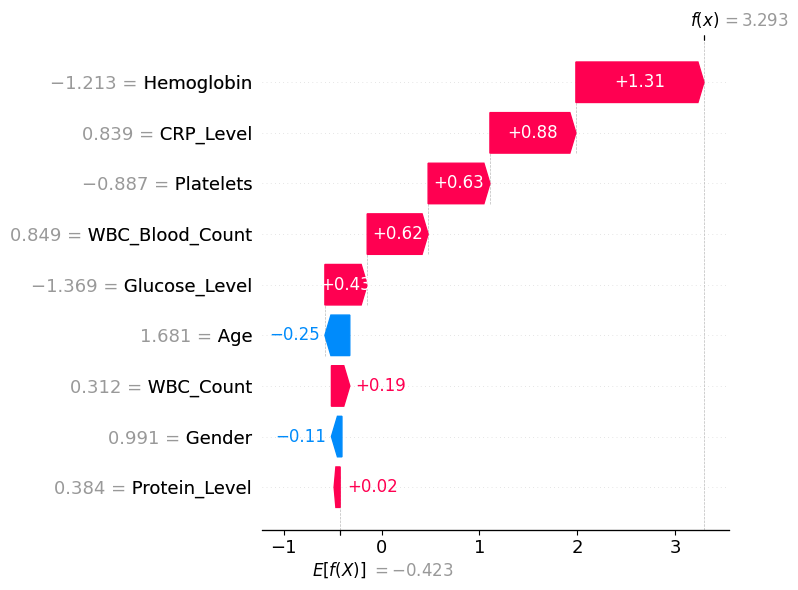

Typical case shown: test index 344, predicted probability 0.964


In [15]:

# Find a high-confidence, correctly predicted Bacterial case for contrast
proba = lr_b.predict_proba(X_test_b_scaled)[:, 1]
preds = lr_b.predict(X_test_b_scaled)
correct_confident_bacterial = np.where((preds == 1) & (y_test_b.values == 1) & (proba > 0.95))[0]

if len(correct_confident_bacterial) > 0:
    pos = correct_confident_bacterial[0]
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.tight_layout()
    plt.savefig("MVB-07-figures/fig-05-waterfall-typical-bacterial.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Typical case shown: test index {X_test_b.index[pos]}, predicted probability {proba[pos]:.3f}")

## Export SHAP Values

In [ ]:

# Save full SHAP values matrix for reference/reuse
shap_df = pd.DataFrame(shap_values.values, columns=feature_set_b_cols)
shap_df.to_csv("MVB-07-results/MVB-07-shap-values.csv", index=False)
print("SHAP values exported:", shap_df.shape)

SHAP values exported: (227, 9)


## Summary

- SHAP `LinearExplainer` applied to the selected model (Logistic Regression, Feature Set B) — exact, non-approximated attributions due to the model's linear structure.
- Global feature importance confirms all coefficient directions align with known clinical patterns (Hemoglobin, CRP, WBC_Count, Platelets, Glucose_Level all push toward Bacterial in the clinically expected direction).
- `Protein_Level` shows near-zero independent influence due to multicollinearity with `WBC_Count` (flagged in Stage 04) — the model is accounting for redundancy, not ignoring the marker.
- Individual explanations for the five Stage 06 false-negative cases visually confirm they are atypical presentations, not model carelessness.
- These findings directly support the Model Card and Pre-Decision Verification Checkpoint documentation in Stage 08.

---

## Stage Status

**Stage:** Completed

**Primary Outputs Produced:**
✓ Global SHAP summary and bar plots (MVB-07-figures/)
✓ Individual case waterfall plots — 5 false negatives + 1 typical case
✓ Coefficient importance table (MVB-07-coefficient-importance.csv)
✓ SHAP global importance table (MVB-07-shap-global-importance.csv)
✓ Full SHAP values export (MVB-07-shap-values.csv)
✓ Explainability notebook
✓ Updated documentation

**Input for Next Stage:**
All Stage 01-07 outputs — Model Card, AI Risk Assessment, and Pre-Decision Verification Checkpoint documentation.

**Next Stage:**
08_MVB_Responsible-AI-Governance — Produce the Model Card, AI Risk Assessment, and formalize the Pre-Decision Verification Checkpoint framework.

In [ ]:

# Notebook completion timestamp and environment info
from datetime import datetime
import platform
import sklearn

print("="*60)
print("Stage 07 completed successfully")
print("Completion time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python:", platform.python_version())
print("Scikit-learn:", sklearn.__version__)
print("SHAP:", shap.__version__)
print("="*60)

Stage 07 completed successfully
Completion time: 2026-07-26 20:00:07
Python: 3.12.13
Scikit-learn: 1.6.1
SHAP: 0.52.0
